# [LAB-08] 2. 단변량 분석 - 연습문제

## #01. 준비작업

### 1. 이전 분석 내용 가져오기

In [3]:
%%capture cap

# 자신의 실습 환경에 맞게 파일 경로 수정하세요
%run "./[LAB-08] PBT - EDAㅣ1-EDA 시작하기(연습문제).ipynb"

### 2. 불러온 내용 확인

In [4]:
print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("연속형   :", continuous_cols)
print("명목형   :", nominal_cols)

display(df.head())
display(desc.head())
display(cat_desc.head())

종속변수 : charges
종속변수 유형: 연속형
연속형   : ['age', 'bmi', 'children']
명목형   : ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log1p


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


### 3. 라이브러리 참조하기

- 여기서는 사용 안함

## #02. 종속변수의 단변량 분석

### 1. 연속형 변수에 대한 분석 수행

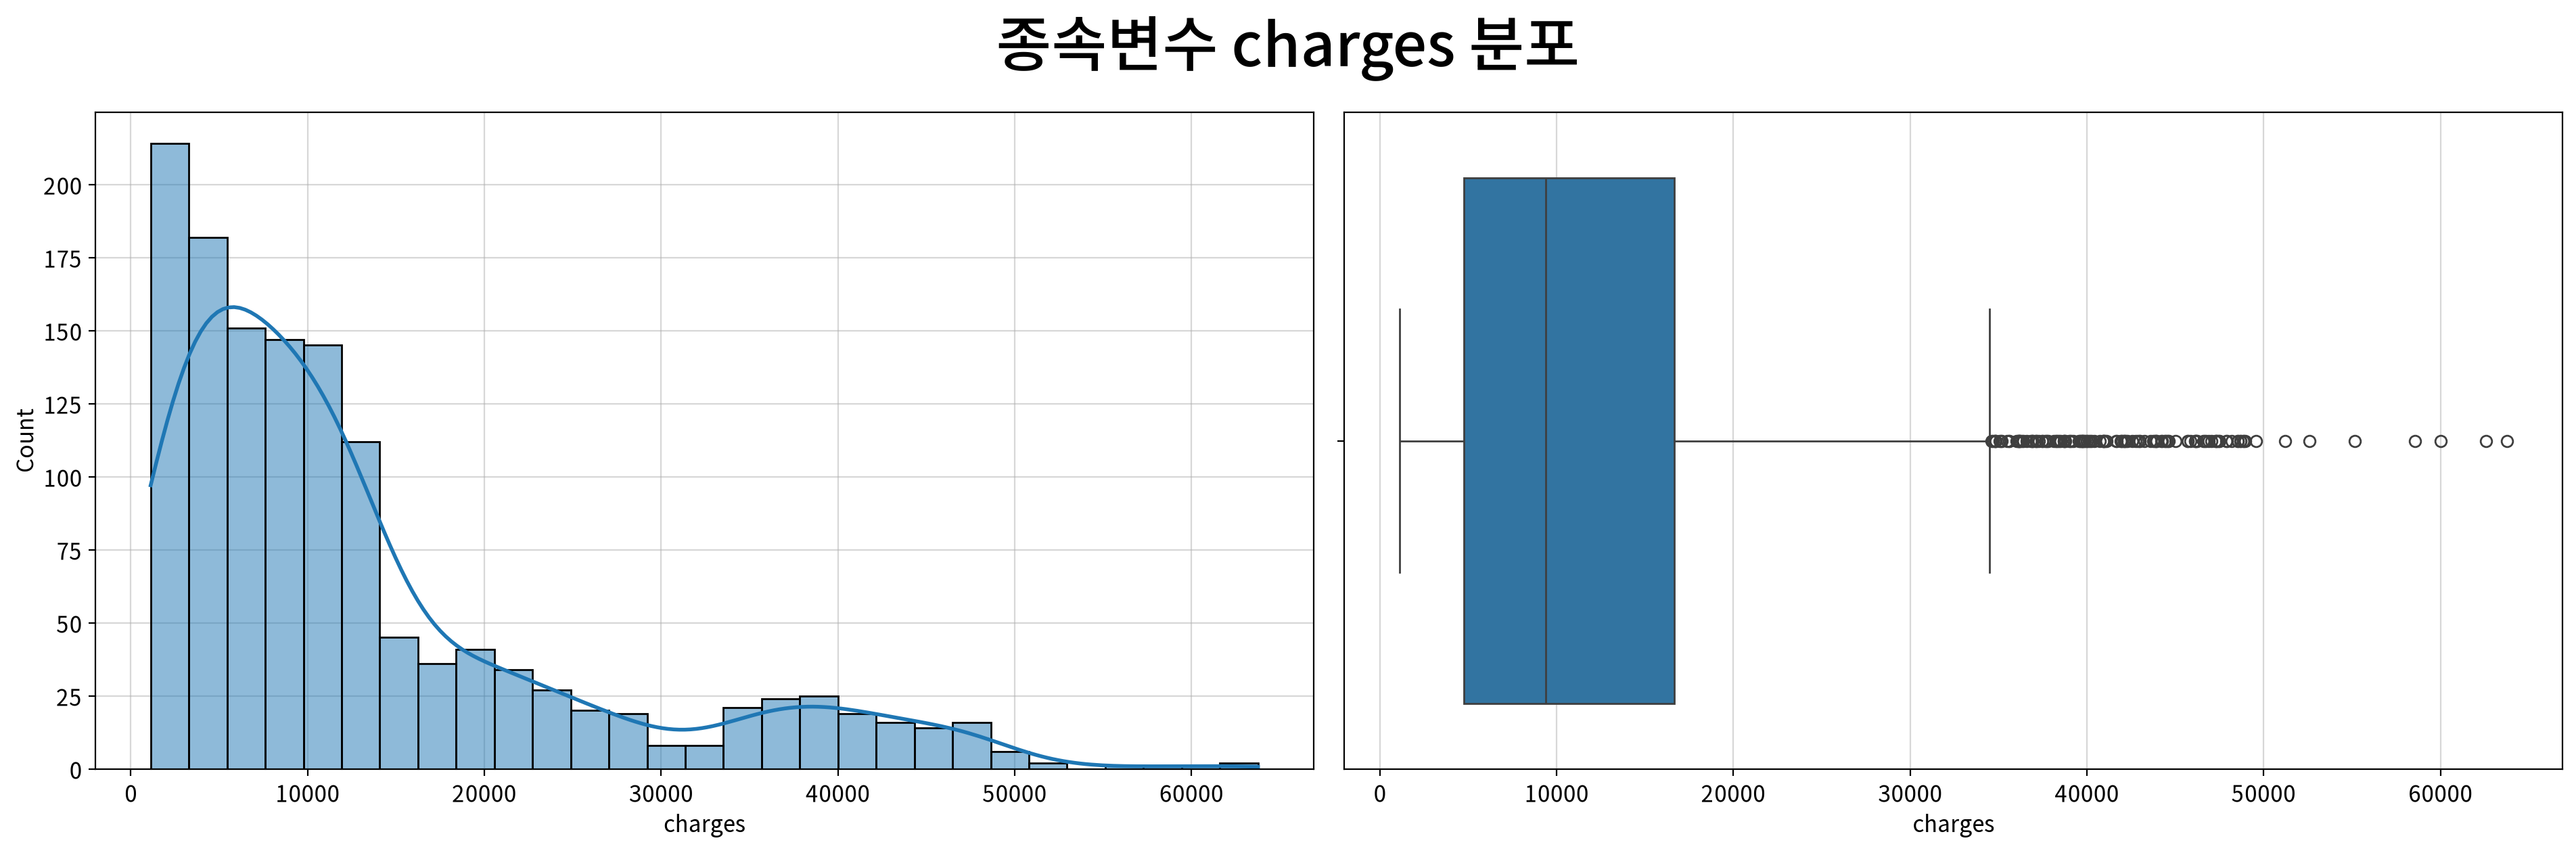

,charges
count,1337.000
mean,13279.121
std,12110.360
min,1121.874
25%,4746.344
50%,9386.161
75%,16657.717
max,63770.428
rel_diff,0.415
rdiff_flag,diff


In [5]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
            title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
desc[desc.index == target].T

#### 💡 인사이트

> 종속변수는 예측 대상이므로 **분포 모양과 변환 필요성**을 가장 먼저 확정한다.
> 모양은 그래프로 보고, 정확한 수치는 함께 출력된 **기술통계량(`desc`) 표**로 확인한다.

| 점검 항목 | `charges`(보험청구비용) 관찰 내용 |
|---|---|
| 분포 모양(왜도) | **강한 우편향** — skew 1.515(`right tail`), 평균 13,279 > 중앙값 9,386 |
| 봉우리 수 | 5,000 부근 주봉 + **35,000~45,000에 2차 봉우리**(KDE) → 고비용 하위집단 암시 |
| 이상치 | 상단에만 139건(**10.4%**), 하단 0건 — 상한 34,525 초과 |
| 첨도 | kurt 1.604(`leptokurtic`) — 중앙 집중 + 두꺼운 오른쪽 꼬리 |
| 값의 범위 | 1,122 ~ 63,770 (최댓값이 중앙값의 약 6.8배) |

**판단·조치**
- 우편향이 뚜렷하므로 회귀 모델 투입 시 **`log1p(charges)` 변환**으로 왜도를 완화한다(`desc`의 `log_need = log1p`와 일치).
- 상단 이상치 10.4%는 **오류가 아니라 실제 고액 청구 집단**으로 보이므로 단순 제거 대상이 아니다.
- 2차 봉우리는 특정 설명변수(예: `smoker`)로 집단이 갈라진다는 신호일 수 있으므로 **이변량 분석에서 확인**한다.

## #03. 독립변수의 단변량 분석

### 1. 연속형 독립변수

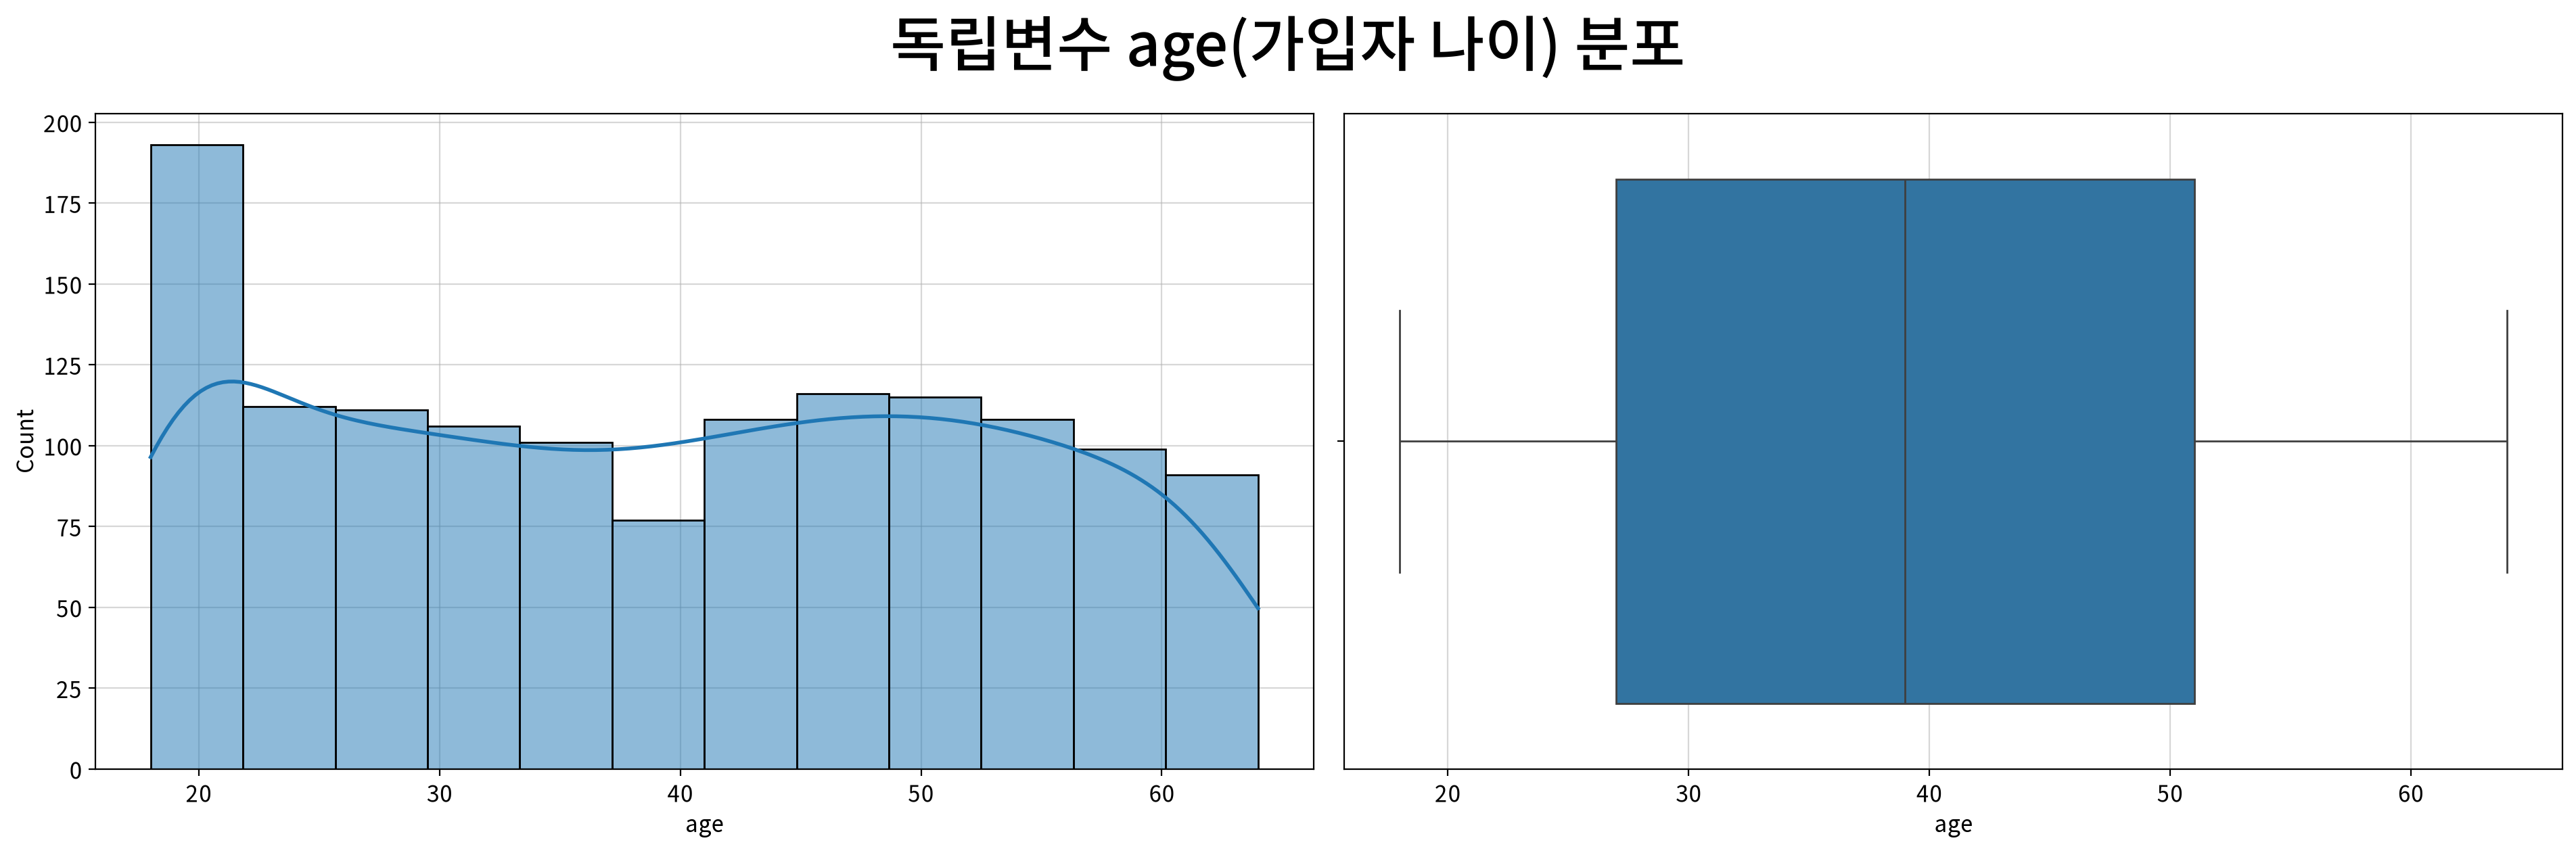

,age
count,1337.000
mean,39.222
std,14.044
min,18.000
25%,27.000
50%,39.000
75%,51.000
max,64.000
rel_diff,0.006
rdiff_flag,similar


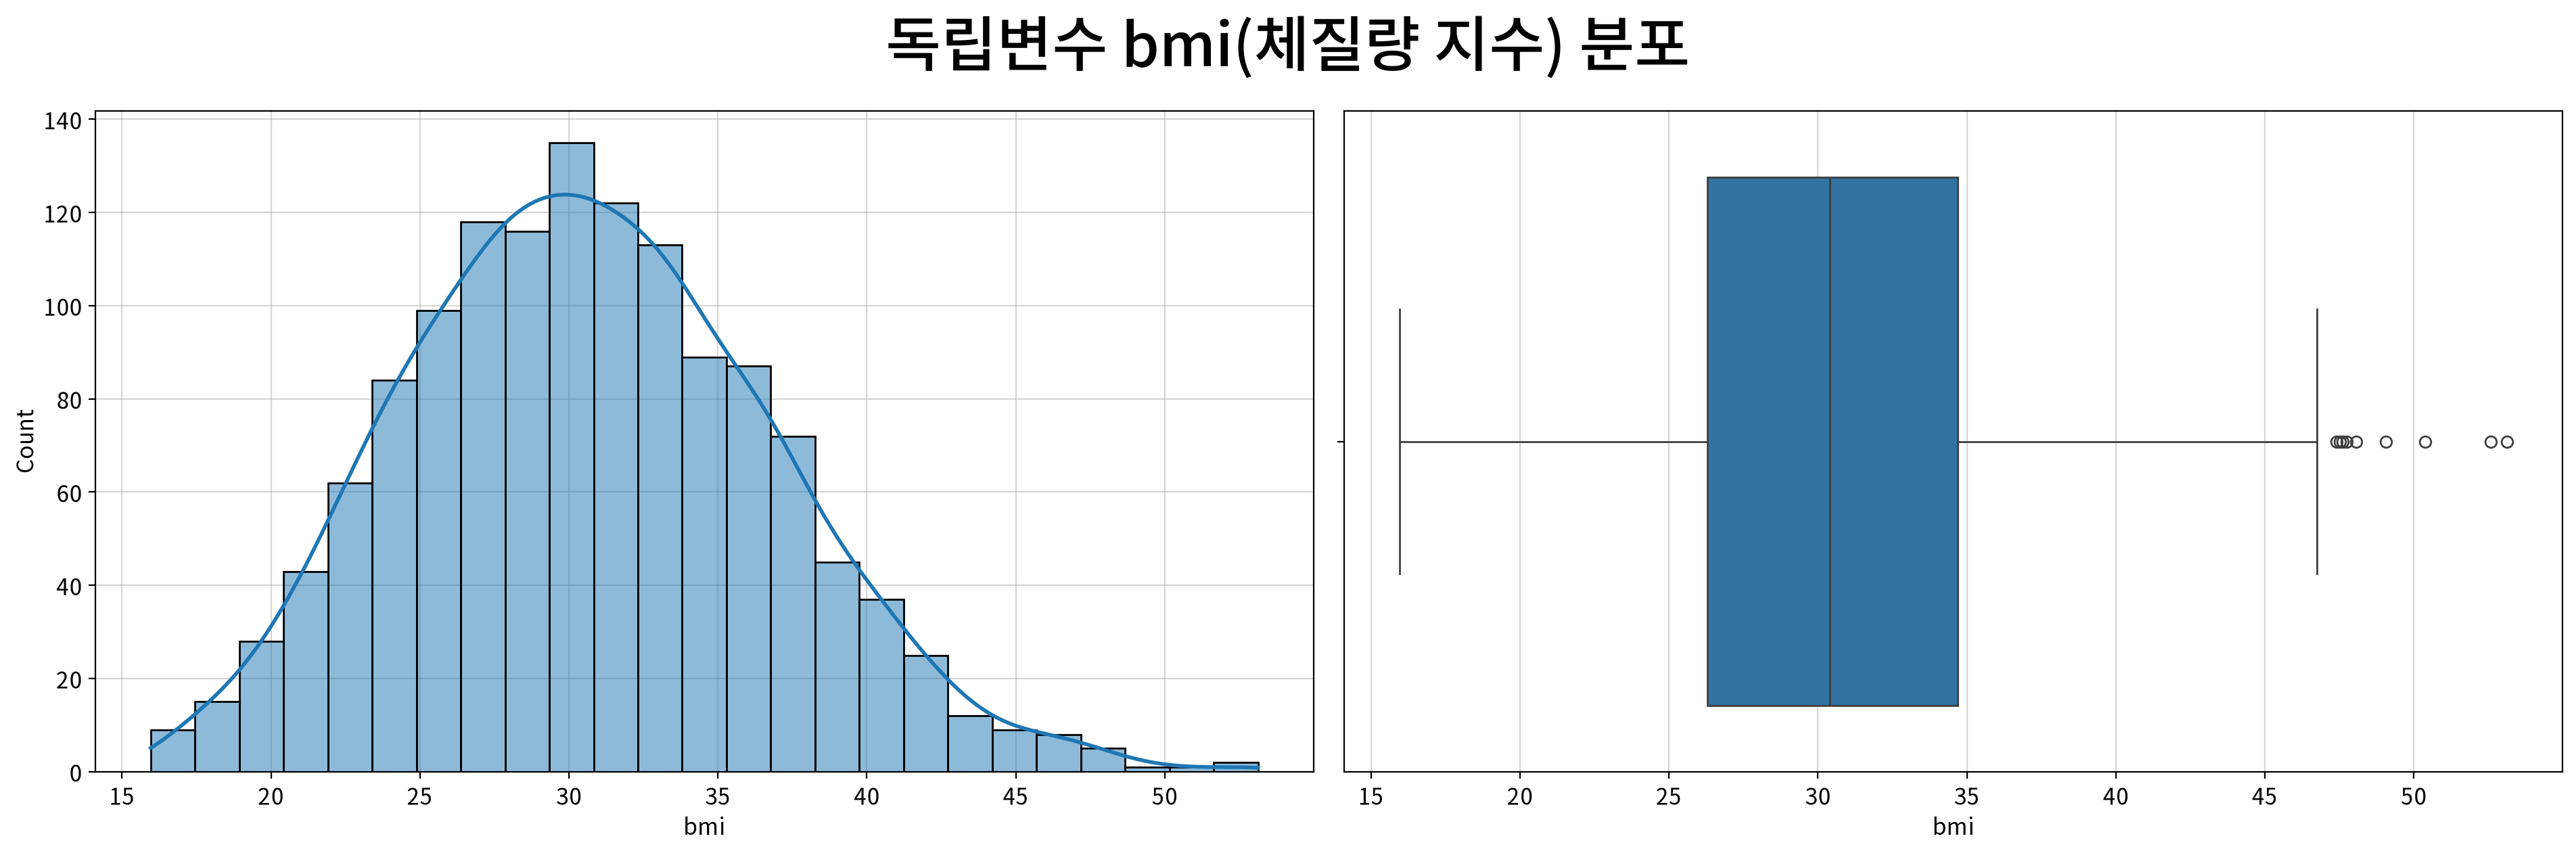

,bmi
count,1337.000
mean,30.663
std,6.100
min,15.960
25%,26.290
50%,30.400
75%,34.700
max,53.130
rel_diff,0.009
rdiff_flag,similar


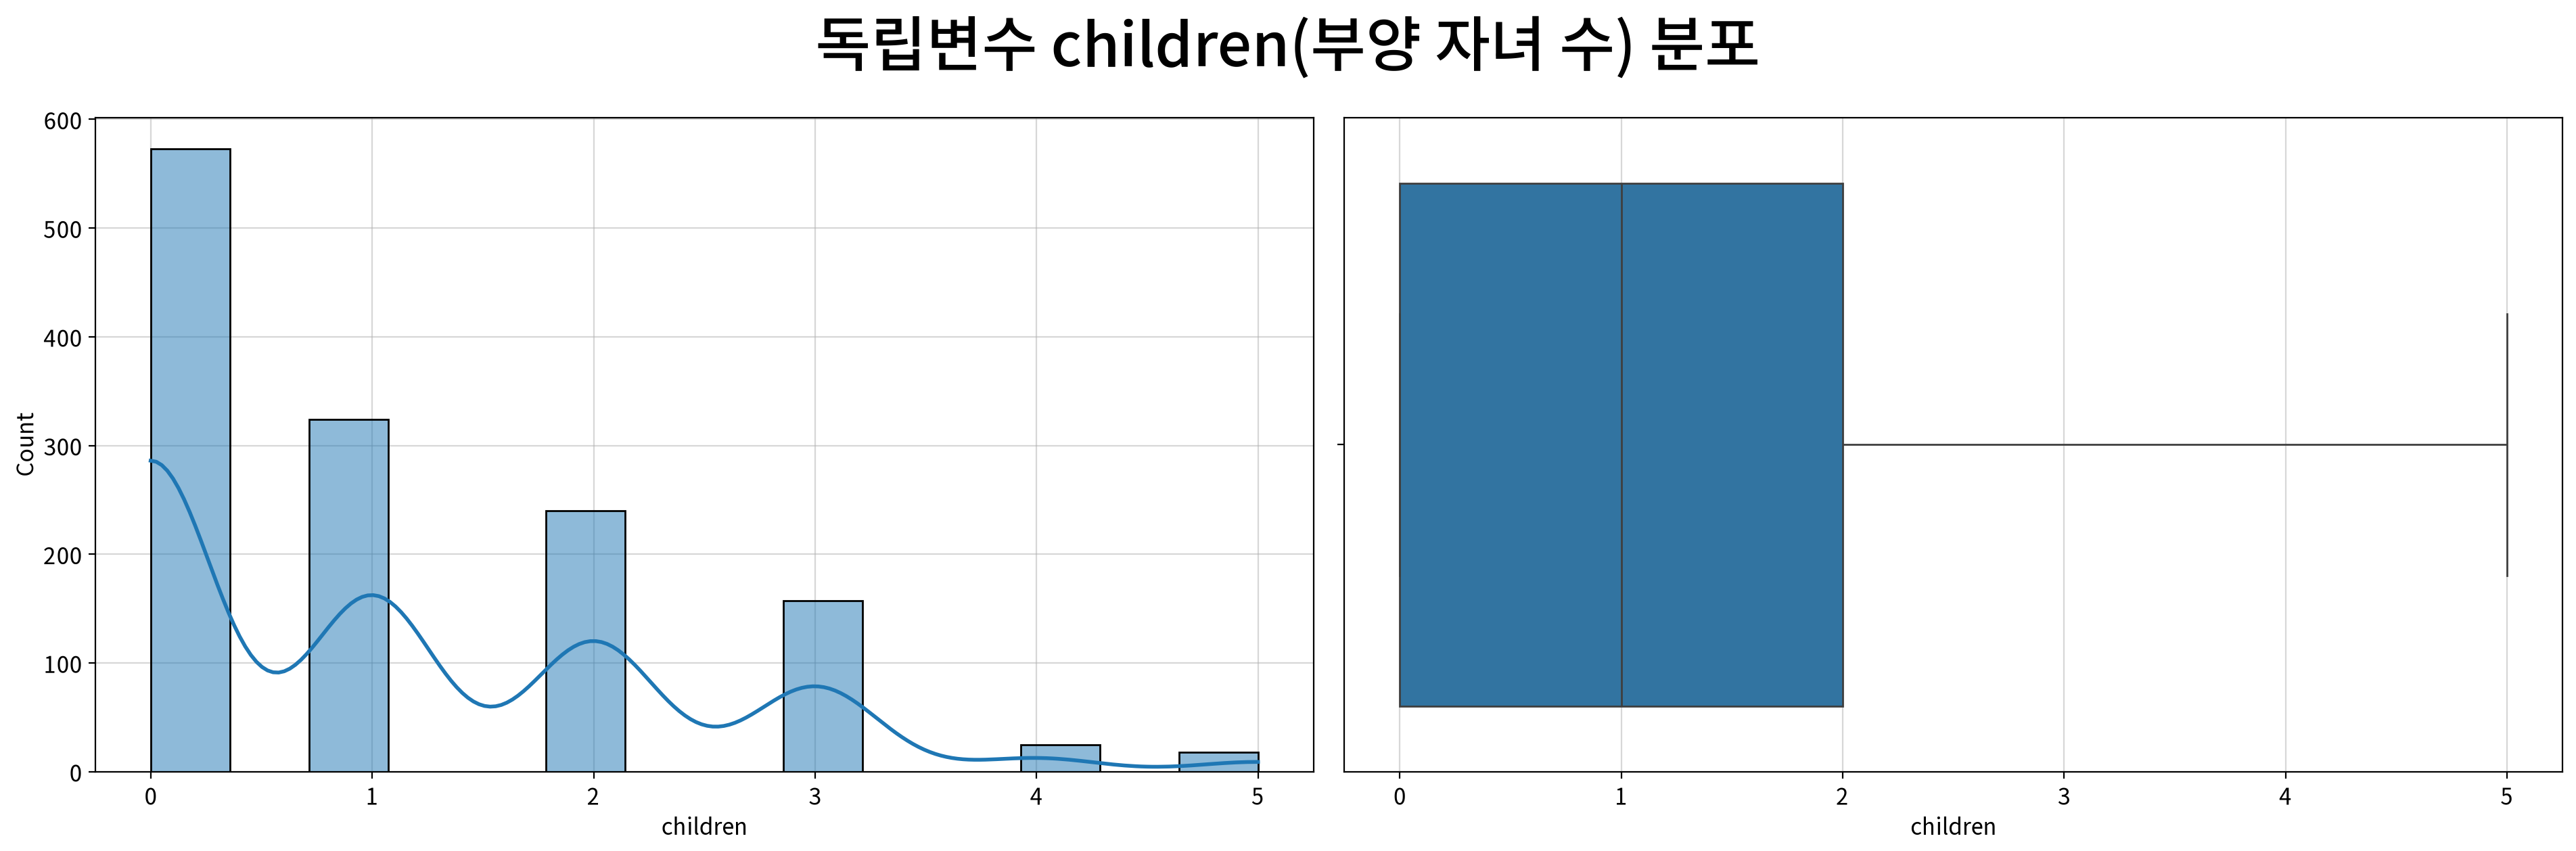

,children
count,1337.000
mean,1.096
std,1.206
min,0.000
25%,0.000
50%,1.000
75%,2.000
max,5.000
rel_diff,0.096
rdiff_flag,similar


In [6]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(desc[desc.index == f].T)

#### 💡 인사이트

> 연속형 독립변수는 **분포 모양 · 봉우리 · 이상치 · 이산성**을 점검해
> "그대로 검정·모델에 넣어도 되는가?"를 판단한다. (수치는 `desc` 표 기준)

| 변수 | 분포 모양(왜도) | 봉우리 | 이상치 | 이산점·군집 | 판단·조치 |
|---|---|---|---|---|---|
| `age`(가입자 나이) | 대칭·**평탄**(skew 0.06, kurt −1.24) | 뚜렷한 단봉 없음 | 없음(0건) | **18~19세에 스파이크**(각 69·67명, 20세 이상 평균 약 27명의 2.5배) | 그대로 사용 가능 |
| `bmi`(체질량 지수) | **거의 대칭**·종 모양(skew 0.28, kurt −0.05) | 단봉(30 부근) | 상단 9건(**0.7%**) | — | 그대로 사용 가능(정규 가정 양호) |
| `children`(부양 자녀 수) | 우편향(skew 0.94) | 0에 최빈(573건) | 없음(0건) | **이산값 0~5뿐**, 4·5는 각 25/18건 | 연속 취급 주의 |

**판단·조치**
- 세 변수 모두 **심한 치우침·과다 이상치 없음 → 로그 변환 불필요**.
- `children`은 `desc`가 `log_need = log1p`로 표시하지만, 이는 skew만 보고 **기계적으로 판정**한 결과다. 값이 6종(0~5)뿐인 **이산 count 변수**라 로그 변환의 실익이 없다. (KDE가 값마다 물결치는 것도 이산 변수에 밀도 곡선을 씌운 착시이므로 봉우리로 읽지 않는다.)
- `age`의 18~19세 스파이크는 청년 가입자가 몰린 **표본 특성**이므로 오류로 보지 않되, 나이 효과 해석 시 감안한다. (히스토그램 첫 막대가 유독 높은 것은 이 스파이크 때문이며, 막대 하나가 약 4개 나이를 묶은 구간임에 주의한다.)
- `age`·`bmi`는 정규 가정이 양호해 **모수 검정(상관·회귀)에 바로 투입 가능**하다.

> `children` 변수 처럼 단순히 기술통계량의 값만 가지고 기계적으로 판별할 경우 값의 범위가 넓지 않은 변수는 큰 변화가 없을 수 있으므로 처리에 주의를 요합니다.

### 2. 명목형 독립변수

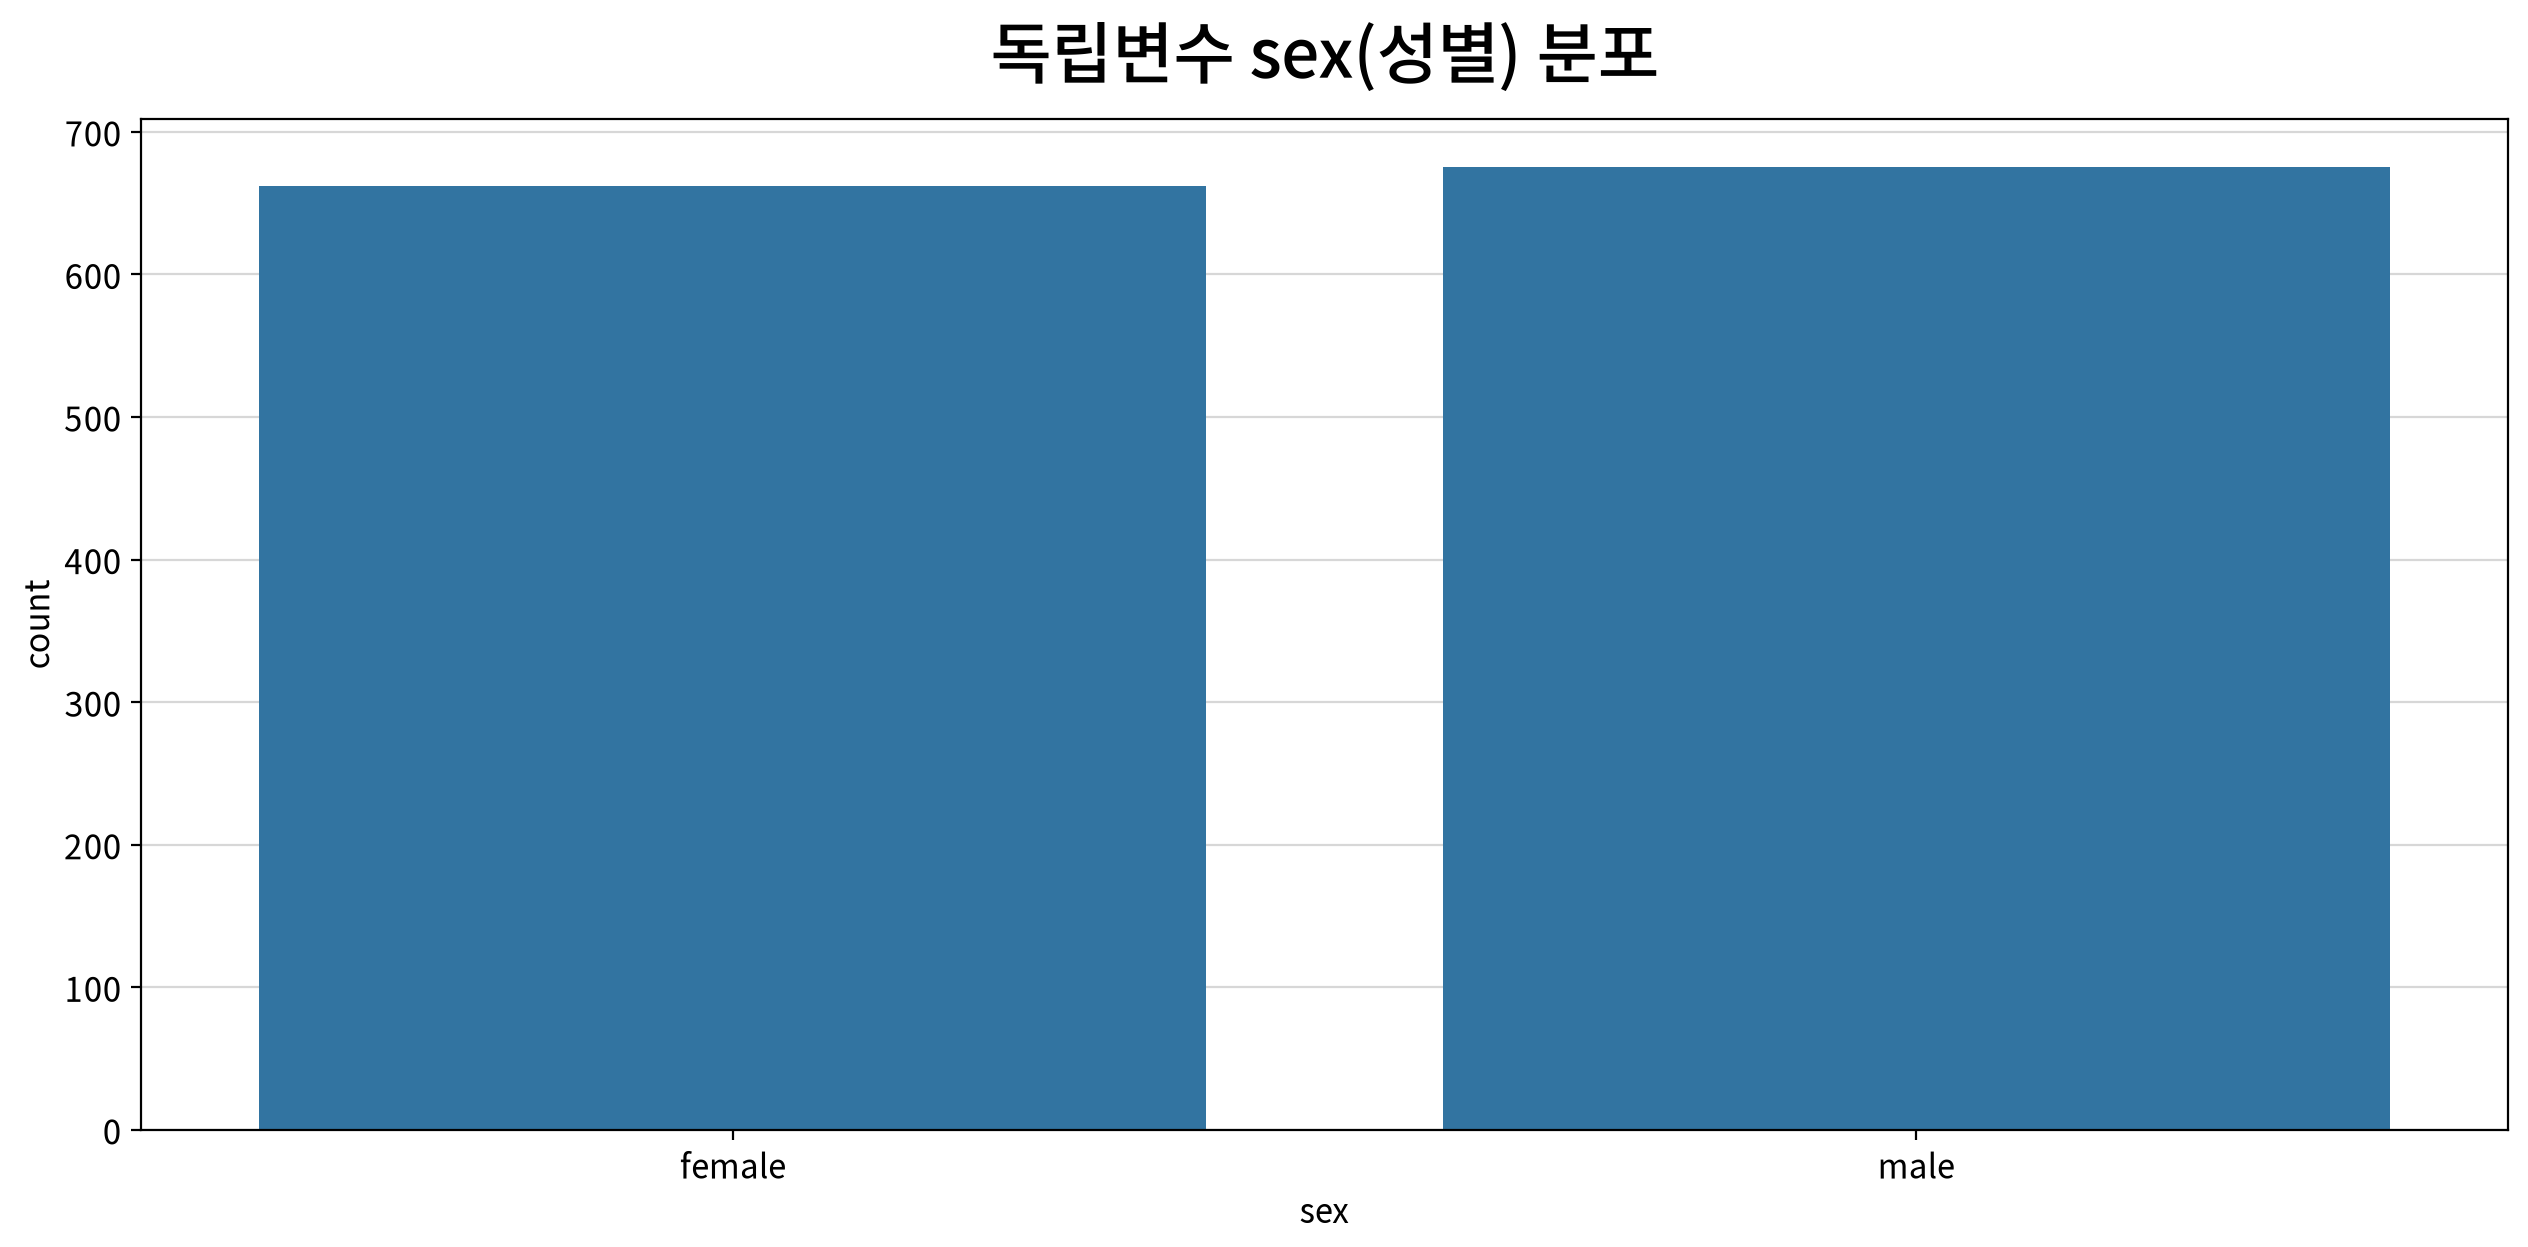

,count,unique,top,freq
sex,1337,2,male,675


,빈도,비율
sex,,
male,675,0.505
female,662,0.495


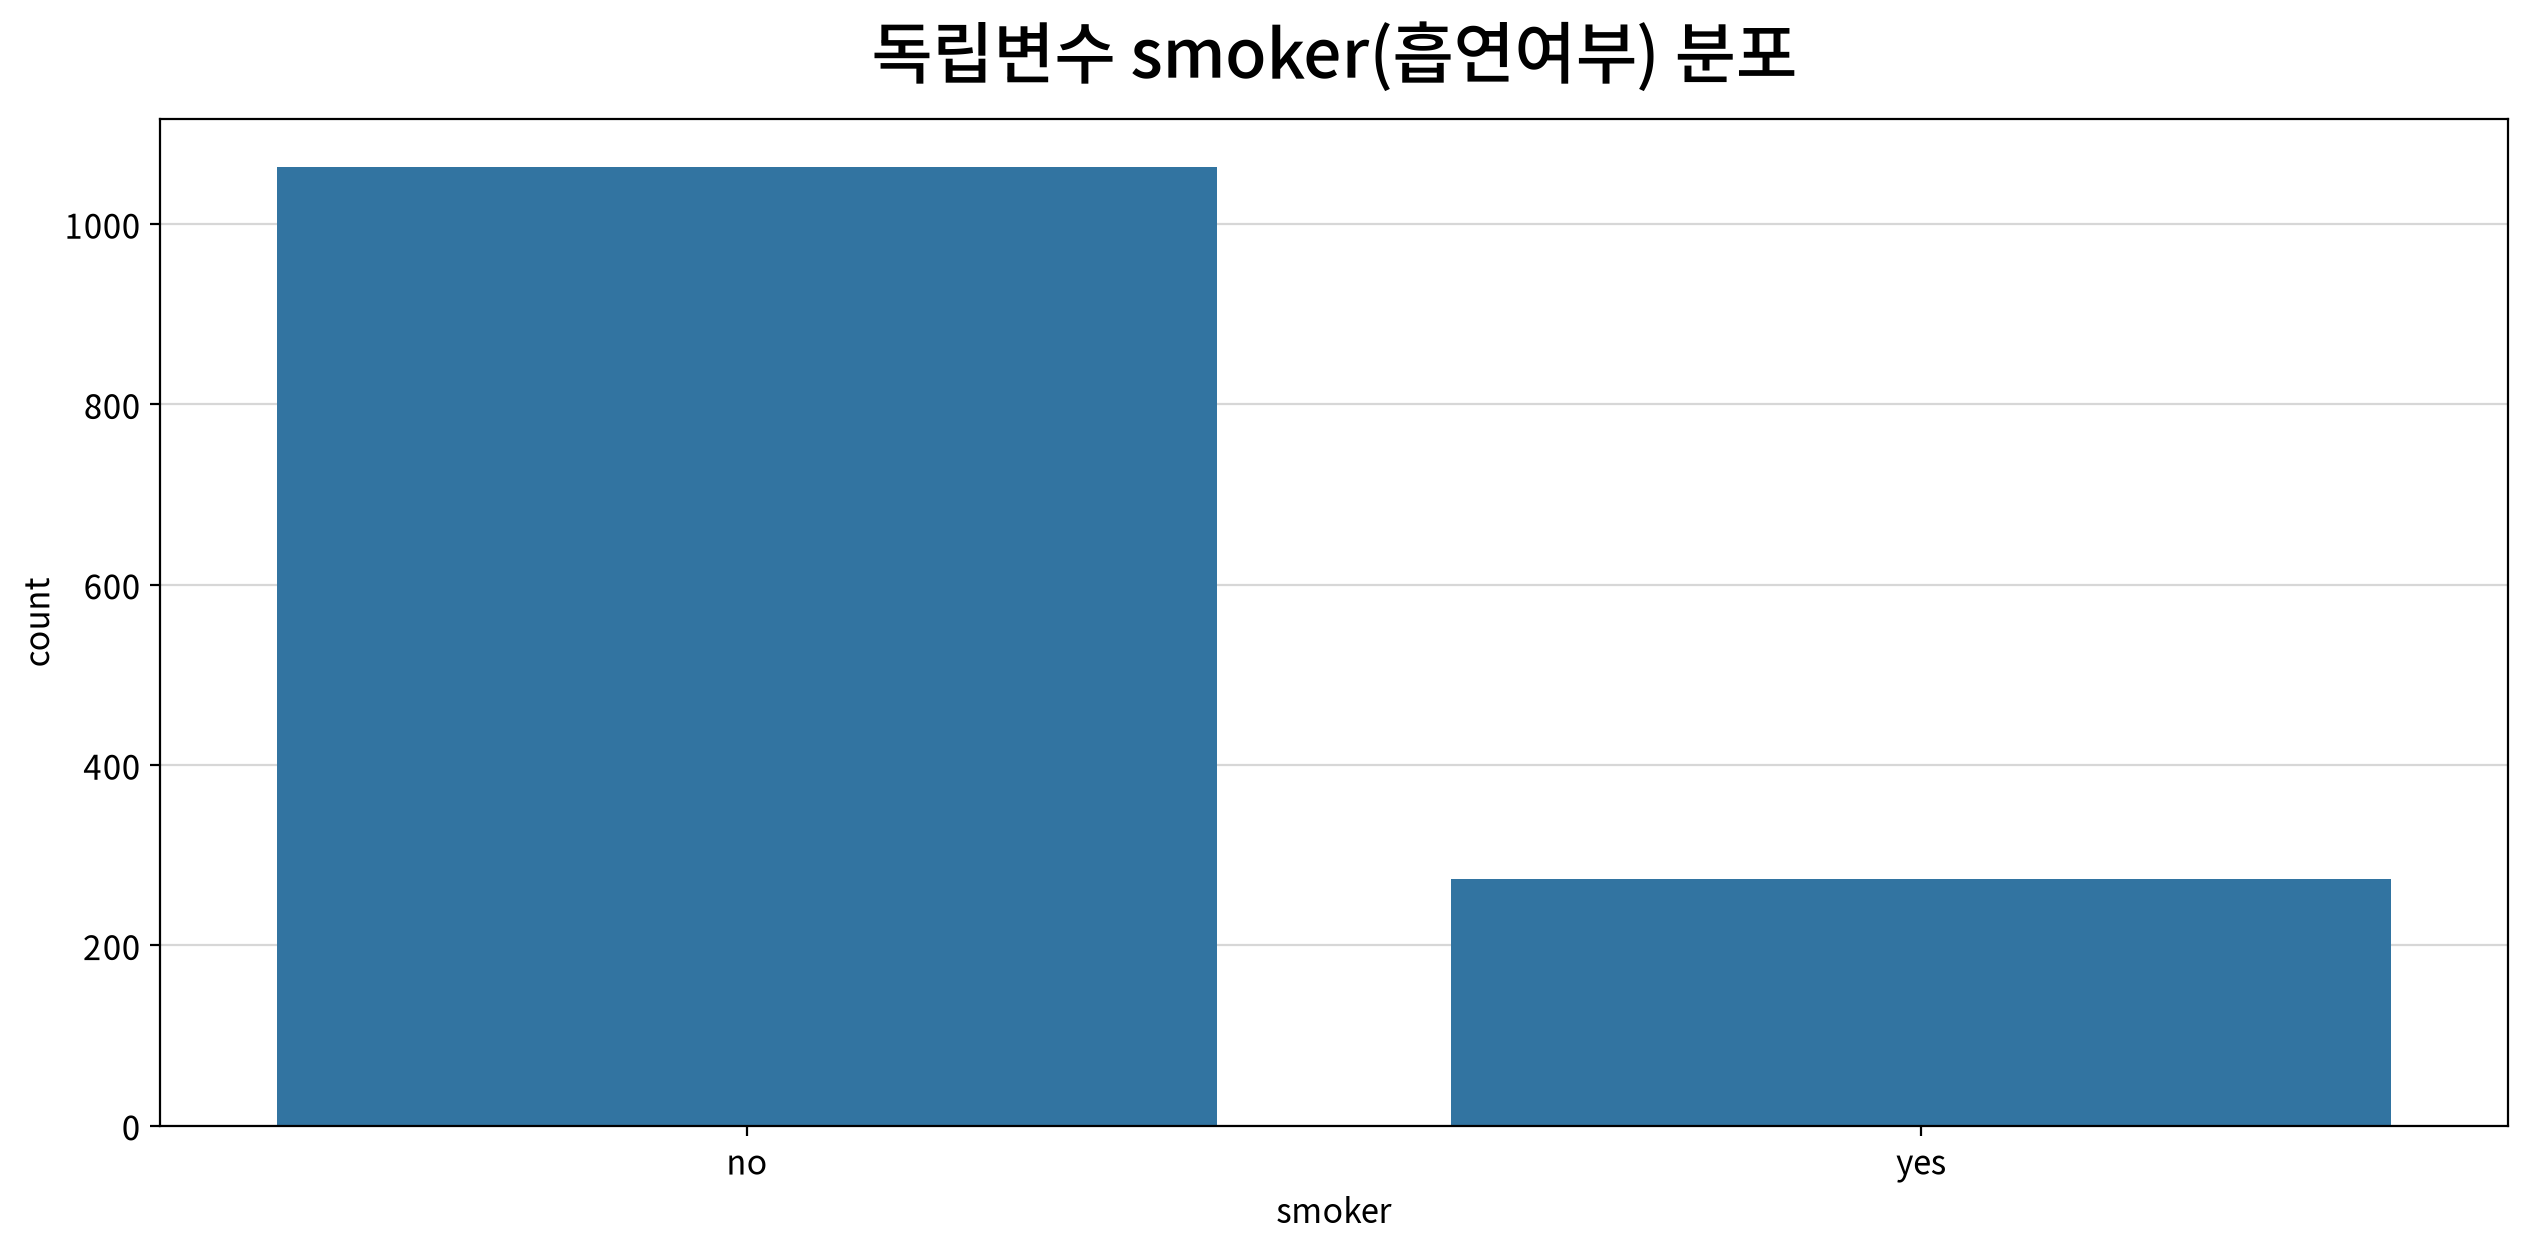

,count,unique,top,freq
smoker,1337,2,no,1063


,빈도,비율
smoker,,
no,1063,0.795
yes,274,0.205


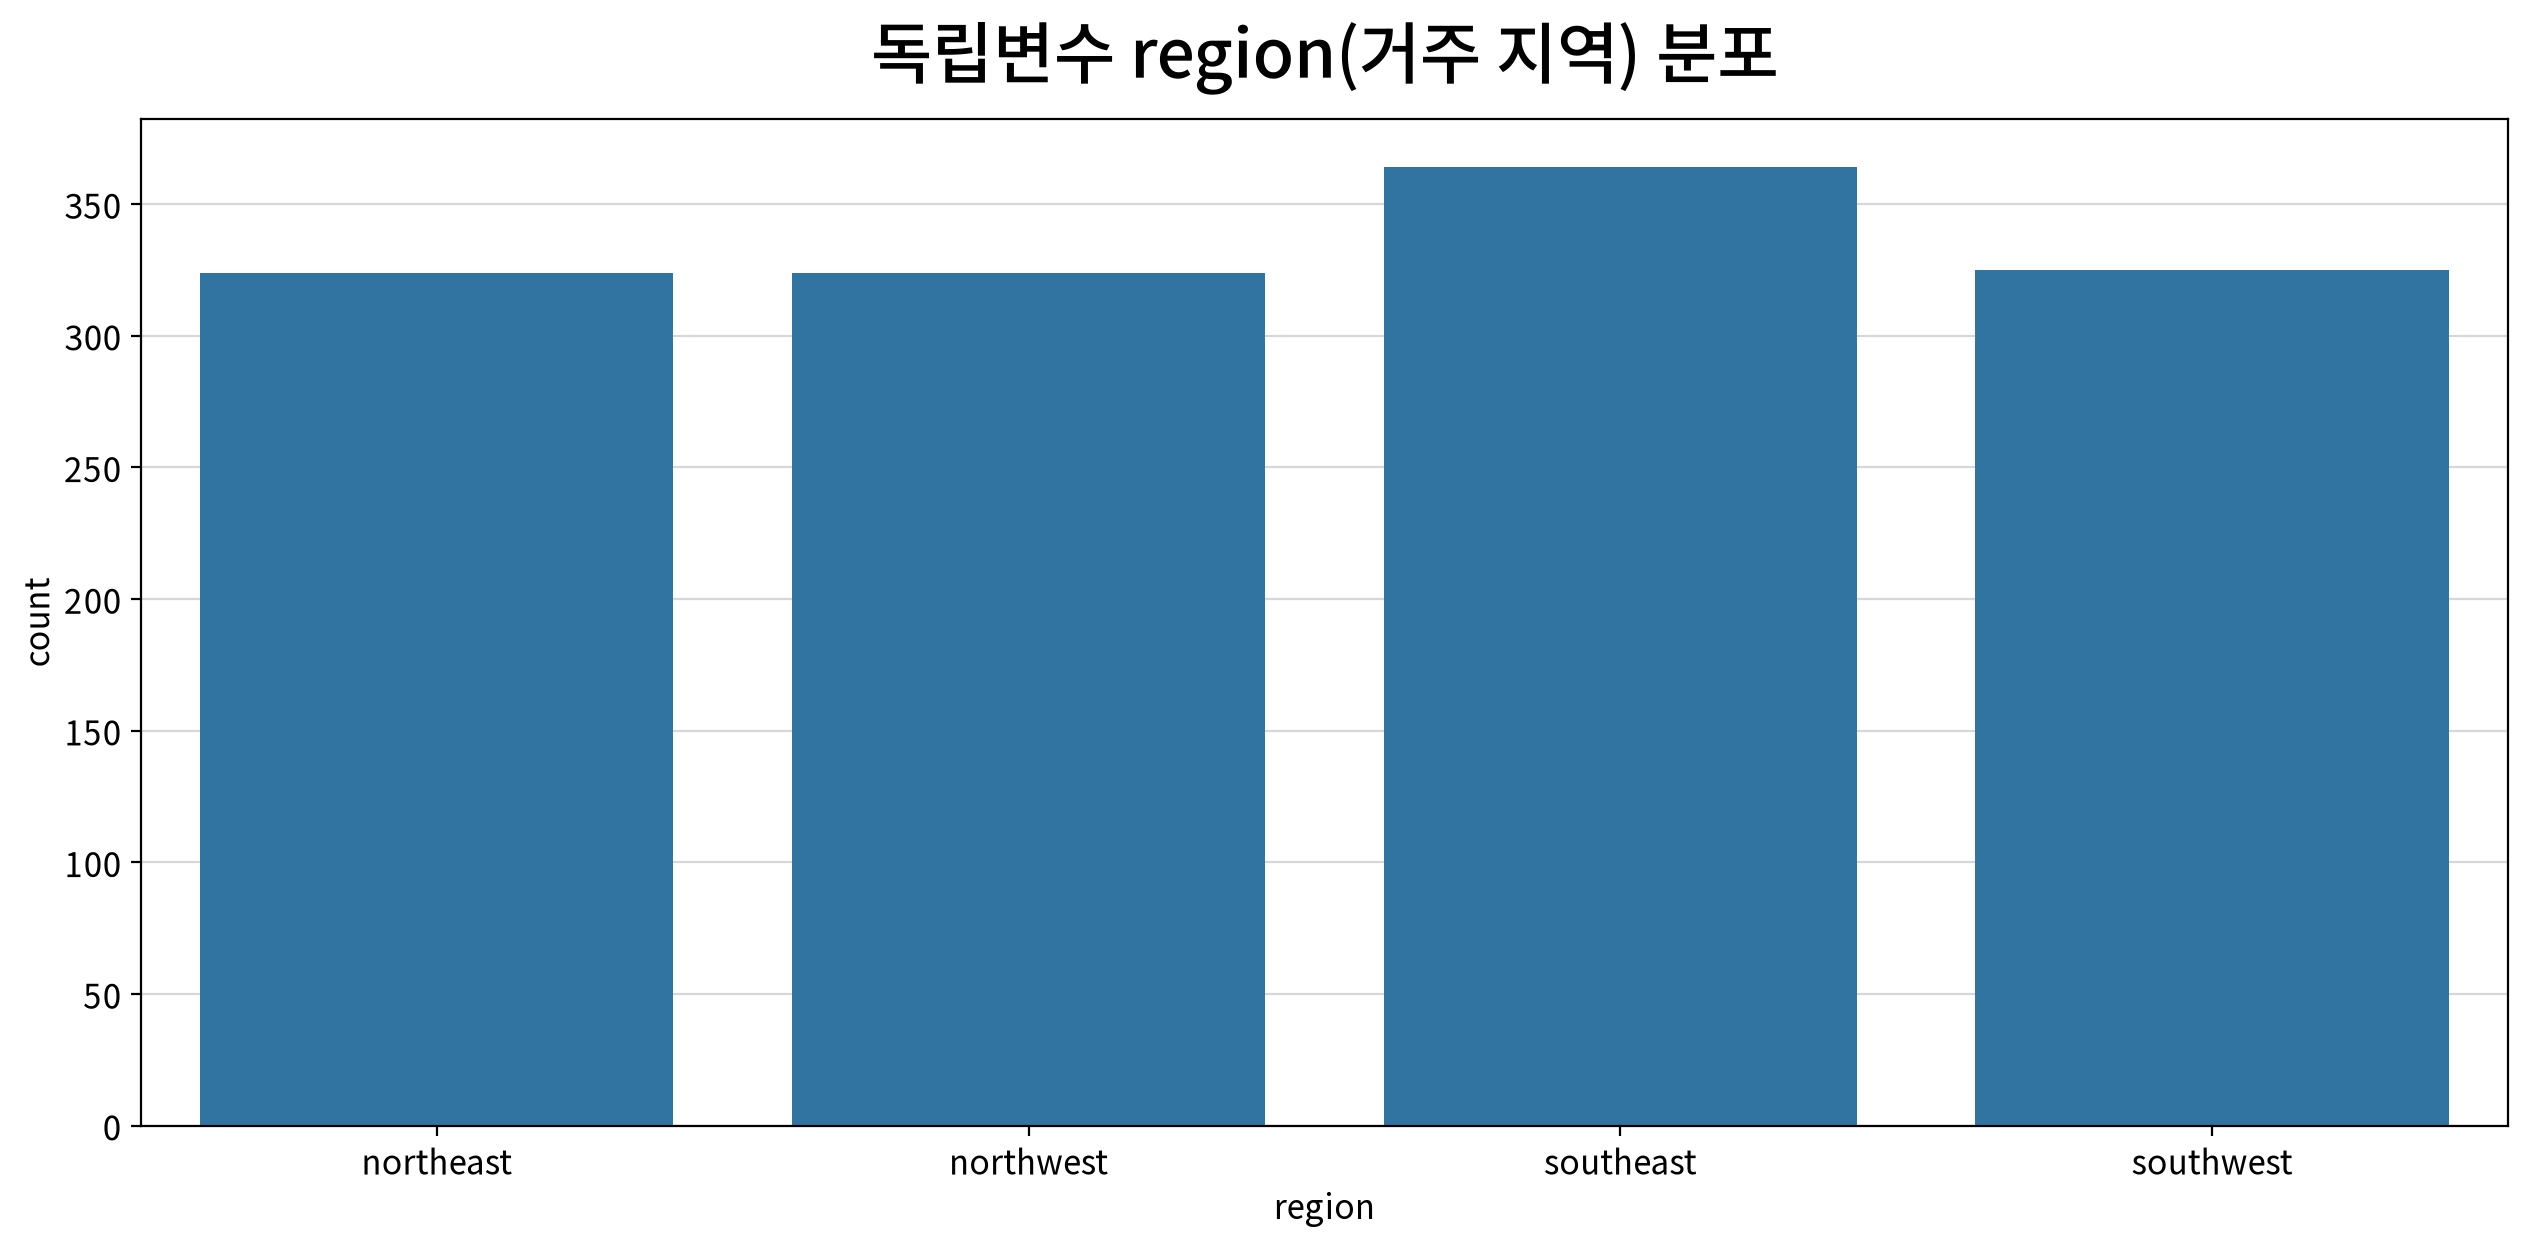

,count,unique,top,freq
region,1337,4,southeast,364


,빈도,비율
region,,
southeast,364,0.272
southwest,325,0.243
northeast,324,0.242
northwest,324,0.242


In [7]:
for n in nominal_cols:
    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

#### 💡 인사이트

> 명목형은 왜도 대신 **범주의 균형/불균형**과 **범주 수(→ 짝이 되는 검정)**를 점검한다.
> 수치는 함께 출력된 **빈도표** 기준이다.

| 변수 | 범주 수 | 빈도(비율) | 균형 여부 | 판단·짝 검정 |
|---|---|---|---|---|
| `sex`(성별) | 2 | male 675(50.5%) / female 662(49.5%) | **균형** | 2집단 → `charges`와 **T검정** |
| `smoker`(흡연여부) | 2 | no 1,063(79.5%) / yes 274(20.5%) | 불균형(흡연 소수) | 2집단 → **T검정**(흡연 274건이라 검정력은 충분) |
| `region`(거주 지역) | 4 | southeast 364(27.2%) / southwest 325(24.3%) / northeast 324(24.2%) / northwest 324(24.2%) | 대체로 균형 | **4집단 → ANOVA** |

**판단·조치**
- 범주 수에 따라 검정을 짝짓는다: **2집단은 T검정**(`sex`, `smoker`), **3집단 이상은 ANOVA**(`region`).
- 모든 범주가 검정 가능한 표본을 확보했으므로 **버릴 변수 없음**.
- `smoker`는 비율상 불균형이지만 소수 집단(흡연)이 종속변수의 **2차 봉우리(고비용 집단)**를 설명할 유력 후보이므로 반드시 유지한다.
- `region`은 각 범주가 비슷한 크기라 ANOVA의 **등분산·표본 균형 조건에 유리**하다.